In [123]:
from typing import Any

import torch
import torch.nn as nn
# from torchvision import models
from torchvision import transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from captum.attr import visualization as viz

# import onnxruntime as ort
import onnx
from onnx2pytorch import ConvertModel

# from tensorflow import keras
# import keras
import os

os.sys.path.append(os.path.dirname(os.path.abspath('.')))

from util import model_utils
from util.attribution_methods import saliencyMethods as attr
from util.attribution_methods import GIGBuilder as GIG_Builder
from util.attribution_methods import AGI as AGI

# autoreload any external modules
# so that any changes are picked up
%load_ext autoreload
%autoreload 2

# configuration
attribution_methods_to_include = {
    "integrated_gradients" : "ig",
    "layer_wise_integrated_gradients" : "lig",
    "integrated_decision_gradients" : "idg",
    "generalized_integrated_gradients" : "gig",
    # "adversarial_gradient_integration" : "agi",
 }

# TODO: export keras/tensorflow ultrasound gesture classifier model
# TODO: import keras/tensorflow ultrasound gesture classifier model here
# model = models.resnet101(weights = "ResNet101_Weights.IMAGENET1K_V2")
# model = model.eval()
# model.to("cuda:0")

# load keras/tensorflow ultrasound gesture classifier model here
keras_model_filepath: str = "/Users/rickgladwin/Code/u_of_hull/dissertation/Acoustic_Gesture_Recognition_v2/results/models/cnn/cnn_perp_subject_4_200_epochs_224px_20260804_124025.keras"

onnx_model_filepath = "/Users/rickgladwin/Code/u_of_hull/dissertation/Acoustic_Gesture_Recognition_v2/results/models/cnn/onnx/cnn_perp_subject_4_200_epochs_224px_20260804_124025.onnx"

# Import onnx model and convert to a PyTorch model that can be used with torchvision code
print(f"Loading model from: onnx_model_filepath\nand converting to PyTorch...")
onnx_model = onnx.load(onnx_model_filepath)
# model = ConvertModel(onnx_model, export_input=True, export_output=True)
# convert onnx model to pytorch model
model = ConvertModel(onnx_model)
# Set the model in evaluation mode (prevents dropout during inference if applicable)
model.eval()

# Get ONNX prediction
# print(f"Loading model from: {onnx_model_filepath}...")
# ort_sess = ort.InferenceSession(onnx_model_filepath)
# onnx_input_name = ort_sess.get_inputs()[0].name


# onnx_pred = ort_sess.run(None, {"input_tensor": dummy_input})[0]
# onnx_pred = ort_sess.run(None, {"input_tensor": test_image})[0]

learning_rate = 1e-5
input_shape = (224, 224, 1)
num_classes = 12

# print(f"Loading model from: {ultrasound_model_filepath}...")
# model = keras.models.load_model(ultrasound_model_filepath, compile=False)
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
#     loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#     metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
# )

# standard image resize dimension for ResNet
img_hw = 224

# transforms for IG, LIG, and IDG
transform = transforms.Compose([
     transforms.Resize((img_hw, img_hw)),
     transforms.CenterCrop(img_hw),
     transforms.ToTensor()
])

# standard ImageNet normalization for IG, LIG, and IDG
transform_normalize = transforms.Normalize(
     mean=[0.485, 0.456, 0.406],
     std=[0.229, 0.224, 0.225]
)

# transforms and normalization for GIG and AGI
resize = transforms.Resize((img_hw, img_hw))
crop = transforms.CenterCrop(img_hw)
# use this version to normalize an image with three channels (RGB)
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
# use this version to normalize an image with one channel (grayscale)
normalize_single_channel = transforms.Normalize(0.485, 0.229)
# normalize ultrasound images for the onnx loaded model
to_tensor = transforms.ToTensor()

# color map for Captum attribution visualization
default_cmap = LinearSegmentedColormap.from_list('custom blue',  [
    (0, '#ffffff'), (0.25, '#0000ff'), (1, '#0000ff')
], N = 256)  

# TODO: address this warning:
# /Users/rickgladwin/Code/u_of_hull/dissertation/Integrated-Decision-Gradients/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
# import pynvml  # type: ignore[import]
# /Users/rickgladwin/Code/u_of_hull/dissertation/Integrated-Decision-Gradients/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
# from .autonotebook import tqdm as notebook_tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading model from: onnx_model_filepath
and converting to PyTorch...


<h1>Load an image and get the class</h1>

In [124]:
import tensorflow as tf

if False:
    # copied from Acoustic_Gesture_Recognition_v2.ultrasound_gesture_cnn_classification.py
    def load_subject_arrays(root: str, mode: str, subject: str, image_size: int):
        """
        Loads and preprocesses ultrasound data for training and testing. This function handles loading of data
        from disk, ensures data consistency, resizes images, normalizes the data, and returns the processed
        datasets along with the number of classes. It is specifically used for preparing ultrasound images for
        machine learning tasks, such as classification or segmentation.
    
        Parameters:
        root: str
            The root directory containing the dataset.
        mode: str
            The mode of data capture, one of ["mirror", "perp"], depending on the orientation of the ultrasound probe.
        subject: str
            Identifier of the subject whose data is to be loaded, one of ["Subject_1", "Subject_2", "Subject_3", "Subject_4", "Subject_5", "Subject_6"].
        image_size: int
            Desired width and height for image resizing. The function assumes a square dimension.
    
        Returns:
        tuple
            A tuple consisting of:
            - (x_train, y_train): Processed training dataset (features, labels).
            - (x_test, y_test): Processed testing dataset (features, labels).
            - num_classes: The total number of unique gesture classes in the dataset (12, for the 2025 mirror/perp dataset).
        """
    
        # example folder path to data:
        # /home/username/ultrasound_gesture_data/mirror/Subject_1/
        d = os.path.join(root, mode, subject)
        x_train = np.load(os.path.join(d, "X_m_train.npy"))
        x_test  = np.load(os.path.join(d, "X_m_test.npy"))
        y_train: np.ndarray = np.load(os.path.join(d, "y_m_train.npy"))
        y_test: np.ndarray  = np.load(os.path.join(d, "y_m_test.npy"))
    
        y_train = y_train.astype(np.int64).ravel()
        y_test  = y_test.astype(np.int64).ravel()
    
        # Ensure channel dim (N, H, W, 1)
        if x_train.ndim == 3: x_train = x_train[..., np.newaxis]
        if x_test.ndim  == 3: x_test  = x_test[..., np.newaxis]
    
        # Resize to image_size (keeps your ViT/CNN parity if you want 320)
        # TODO: look at converting to tensors that can be used with MPS optimization
        x_train = tf.image.resize(tf.convert_to_tensor(x_train), (image_size, image_size)).numpy()
        x_test  = tf.image.resize(tf.convert_to_tensor(x_test ), (image_size, image_size)).numpy()
    
        # Normalize to [0,1]
        if x_train.dtype != np.float32:
            x_train = x_train.astype("float32"); x_test = x_test.astype("float32")
        maxv = max(float(x_train.max()), 1.0)
        x_train /= maxv; x_test /= maxv
    
        class_count = int(max(y_train.max(), y_test.max()) + 1)
        return (x_train, y_train), (x_test, y_test), class_count


Image shape: torch.Size([1, 224, 224])
Image dtype: torch.float32
Image max: 0.9921568632125854
Unsqueezed input_img shape: torch.Size([1, 1, 224, 224])
Unsqueezed input_img dtype: torch.float32
Unsqueezed input_img max: 0.9921568632125854
CUDA available:  False
MPS available:   True
Device name:     mps
target_class for example image img/ultrasound_subject_4_gesture_0_x_test_0_example.png: 0
name for target_class 0: IndFlex
model_utils.getPrediction():
88.8433 IndFlex


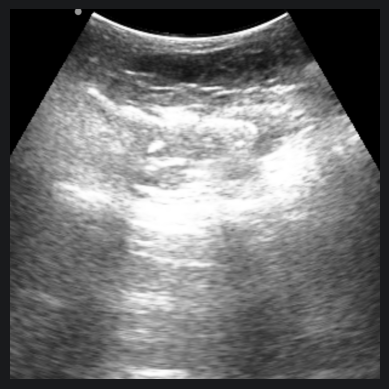

In [125]:
from PIL.ImageFile import ImageFile

# TODO: import example images from each gesture class
# TODO: get the class for each image
# image_path = "img/jet.jpg"
# img = Image.open(image_path)

# image_path = "img/ultrasound_subject_4_gesture_0_example.png"
image_path = "img/ultrasound_subject_4_gesture_0_x_test_0_example.png"
img: ImageFile = Image.open(image_path, formats=["PNG"])

trans_img = transform(img)
print(f"Image shape: {trans_img.shape}")
print(f"Image dtype: {trans_img.dtype}")
print(f"Image max: {trans_img.max()}")

# single sample shapes in PyTorch are torch.Size([channels, height, width])
# input_img = normalize(trans_img)
image_channels = trans_img.shape[0] # 1 for grayscale, 3 for RGB

# input_img = normalize_single_channel(trans_img)
# NOTE: transform(img) already includes transforms.ToTensor()
# input_img = to_tensor(trans_img)
# print(f"Normalized shape: {input_img.shape}")
# print(f"Normalized image max: {input_img.max()}")
# print(f"Normalized image dtype: {input_img.dtype}")
# input_img = input_img.unsqueeze(0)
input_img = trans_img.unsqueeze(0)
print(f"Unsqueezed input_img shape: {input_img.shape}")
print(f"Unsqueezed input_img dtype: {input_img.dtype}")
print(f"Unsqueezed input_img max: {input_img.max()}")
# example unsqueezed shape: torch.Size([1, 1, 224, 224])
# PyTorch uses NCHW format, so this represents torch.Size([batch, channels, height, width])

# check available devices
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"MPS available:   {torch.backends.mps.is_available()}")
print(f"Device name:     {'mps' if torch.backends.mps.is_available() else 'cpu'}")

# device = "cuda:0"
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# override device to cpu
# TODO: after getting this to run on CPU, reintroduce MPS
# device = "cpu"

# configure the model for the device
model.to(device)

# TODO: check model.to(device) and tensor = tensor.to(device)

# copied from tensorflow_image_classifier_explainability/integrated_gradients_ultrasound.ipynb
# gesture class index (0-11) and class shortnames
gesture_class_index_and_shortnames: list[tuple[int, str]] = [
    (0, "IndFlex"),
    (1, "MidFlex"),
    (2, "RinFlex"),
    (3, "PinFlex"),
    (4, "IndPinch"),
    (5, "IndMidPinch"),
    (6, "IndMidRinPinch"),
    (7, "AllPinch"),
    (8, "MidRinPinch"),
    (9, "Fist"),
    (10, "Hook"),
    (11, "Open"),
]

classes = [shortname for _, shortname in gesture_class_index_and_shortnames]

target_class = model_utils.getClass(input_img, model, device)
print(f"target_class for example image {image_path}: {target_class}")
# open the class list so the detected class string can be returned for printing
# with open('../util/class_maps/ImageNet/imagenet_classes.txt') as f:
#     classes = [line.strip() for line in f.readlines()]
name = classes[target_class]
print(f"name for target_class {target_class}: {name}")
print(f"model_utils.getPrediction():")
print(model_utils.getPrediction(input_img, model, device, target_class)[0] * 100, name)

plt.axis("off")

# use gray colormap for grayscale (single channel) images
if image_channels == 1:
    img_colormap = plt.get_cmap('gray')
else:
    img_colormap = None

plt.imshow(img, cmap=img_colormap)
plt.show()

<h1>Generate attributions</h1>

In [126]:
steps = 50
batch_size = 25
# TODO: change the naming here, or change how the default parameters are declared.
#  The type of the `baseline` variable changes from int to a pytorch tensor.
baseline = 0 # this will result in a black baseline by default

Gradients for ultrasound image classifiers work better with a custom baseline rather than a black baseline, since 
a) black has a specific meaning in an ultrasound image within the beam (regions of low density), and 
b) there are regions in the image that are outside the representation of the "beam" that are black and carry a different meaning (a lack of information).

We will use a custom baseline that is the average of all ultrasound images in the dataset that are not of the target class.

In [130]:
# build "out of class average baseline" for ultrasound class 0

# load ultrasound image data
# modified version of loading code from Claude Code (2026)
import numpy as np

train_image_source_file = "/Users/rickgladwin/Code/u_of_hull/dissertation/bimbraw_2025_dataset/data/perp/Subject_4/X_m_train.npy"
print(f"loading image data from {train_image_source_file}")
train_image_data = np.load(train_image_source_file)

print(f"train_image_data.shape: {train_image_data.shape}")

# ensure 4D SHAPE (batch, height, width, channels) before resizing
if train_image_data.ndim == 3:
    print(f"expanding dims...")
    train_image_data = np.expand_dims(train_image_data, axis=-1)

# excerpt from Gemini 3 Flash (2026a)
# Process in batches to prevent tensorflow-metal memory failure
BATCH_SIZE = 500
resized_batches = []

print(f"Resizing {len(train_image_data)} images in batches...")
for steps_option in range(0, len(train_image_data), BATCH_SIZE):
    batch = train_image_data[steps_option: steps_option + BATCH_SIZE]

    # Convert and resize a smaller chunk
    res = tf.image.resize(
        tf.constant(batch, dtype=tf.float32),
        size=(240, 240),
        preserve_aspect_ratio=True,
        method="bilinear",
    )
    res = tf.image.resize_with_pad(res, target_height=224, target_width=224)

    # Optional: Normalize to [0, 1] while still in float
    if tf.reduce_max(res) > 1.0:
        res = res / 255.0

    resized_batches.append(res)
    print(f"Processed up to {steps_option + len(batch)}")

# Combine everything back into one tensor
train_image_tensor = tf.concat(resized_batches, axis=0)
print(f"Final train_image_tensor.shape: {train_image_tensor.shape}")

# -- end memory-safe code

# get a tensor with the class labels
class_source_file = "/Users/rickgladwin/Code/u_of_hull/dissertation/bimbraw_2025_dataset/data/perp/Subject_4/y_m_train.npy"
print(f"loading class data from {class_source_file}")
class_data = np.load(class_source_file)

print(f"class_data.shape:   {class_data.shape}")

loading image data from /Users/rickgladwin/Code/u_of_hull/dissertation/bimbraw_2025_dataset/data/perp/Subject_4/X_m_train.npy
train_image_data.shape: (4800, 640, 640, 1)
Resizing 4800 images in batches...
Processed up to 500
Processed up to 1000
Processed up to 1500
Processed up to 2000
Processed up to 2500
Processed up to 3000
Processed up to 3500
Processed up to 4000
Processed up to 4500
Processed up to 4800
Final train_image_tensor.shape: (4800, 224, 224, 1)
loading class data from /Users/rickgladwin/Code/u_of_hull/dissertation/bimbraw_2025_dataset/data/perp/Subject_4/y_m_train.npy
class_data.shape:   (4800,)


Next we will remove all images from the training set that belong to the target class.

In [131]:
# compute the test class index from the test class name
# get the index in the class vocabulary corresponding to the target class name
test_class = name # e.g. "IndPinch"

target_model_class_index: int = -1
for key, value in gesture_class_index_and_shortnames:
    print(f"key: {key}, value: {value}")
    if value == test_class: # e.g. "IndPinch"
        target_model_class_index = key
        break

if target_model_class_index == -1:
    raise ValueError(f"Could not find target class {test_class} in gesture_class_index_and_shortnames")


# get just the out-of-class images
print(f"test_class:               {test_class}")               # e.g. "IndPinch"
print(f"target_model_class_index: {target_model_class_index}") # e.g. 4

print(f"all image count: {train_image_tensor.shape[0]}")
print(f"getting just the out-of-class images...")
out_of_class_indices = np.where(class_data != target_model_class_index)[0]
out_of_class_indices = tf.convert_to_tensor(out_of_class_indices)
print(f"out_of_class_indices.shape: {out_of_class_indices.shape}")
print(f"out_of_class_indices.dtype: {out_of_class_indices.dtype}")

out_of_class_images = tf.gather(train_image_tensor, out_of_class_indices)
out_of_class_labels = tf.gather(class_data, out_of_class_indices)

print(f"out_of_class_images.shape: {out_of_class_images.shape}")
print(f"out_of_class_labels.shape: {out_of_class_labels.shape}")

key: 0, value: IndFlex
test_class:               IndFlex
target_model_class_index: 0
all image count: 4800
getting just the out-of-class images...
out_of_class_indices.shape: (4400,)
out_of_class_indices.dtype: <dtype: 'int64'>
out_of_class_images.shape: (4400, 224, 224, 1)
out_of_class_labels.shape: (4400,)


Now we can average the out-of-class images to produce a baseline image.

avg_out_of_class_image:


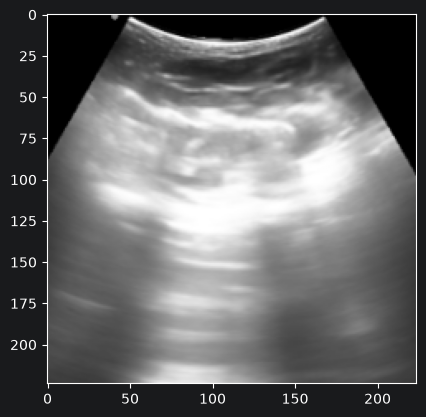

In [132]:
# average the out-of-class images
# -- excerpt from Gemini 3 Flash (2026b)

# Use TensorFlow's native mean function on the tensor
avg_out_of_class_image = tf.math.reduce_mean(out_of_class_images, axis=0)
print(f"avg_out_of_class_image:")
# To visualize it with plt.imshow, convert to numpy and squeeze
plt.imshow(np.squeeze(avg_out_of_class_image.numpy()), cmap='gray')
plt.show()

# -- end excerpt



In [168]:
call_model_args: dict[str, Any] = {'class_idx_str': target_class.item()}
guided_ig = GIG_Builder.GuidedIG()

# shape of input_img used for the gradient calculation
# the baseline shape must match this shape
print(f"input_img.shape: {input_img.shape}")

# baseline = torch.zeros_like(input_img)
# print(f"baseline.shape: {baseline.shape}")
baseline_black = torch.zeros_like(input_img)
print(f"baseline_black.shape: {baseline_black.shape}")

baseline_numpy = avg_out_of_class_image.numpy()
print(f"ultrasound baseline_numpy.shape: {baseline_numpy.shape}")
# permute and unsqueeze to go from (H, W, C) to (N, C, H, W)
baseline_tensor = torch.from_numpy(baseline_numpy)
baseline_tensor = baseline_tensor.permute(2, 0, 1)
print(f"baseline_tensor.shape: {baseline_tensor.shape}")
baseline = baseline_tensor.unsqueeze(0)
print(f"baseline.shape: {baseline.shape}")

# TODO: ** get baseline working

gig = guided_ig.GetMask(input_img, model, device, GIG_Builder.call_model_function, call_model_args, x_baseline=baseline, x_steps=50, max_dist=1.0, fraction=0.5)

input_img.shape: torch.Size([1, 1, 224, 224])
baseline_black.shape: torch.Size([1, 1, 224, 224])
ultrasound baseline_numpy.shape: (224, 224, 1)
baseline_tensor.shape: torch.Size([1, 224, 224])
baseline.shape: torch.Size([1, 1, 224, 224])


Build the attributions for IG, LIG, and IDG

In [186]:
# alpha star = 1, plain IG attribution
ig = attr.IG(input=input_img, model=model, steps=steps, batch_size=batch_size, alpha_star=1, baseline=baseline, device=device, target_class=target_class)

In [187]:
# alpha star = 0.9, Left IG attribution
# TODO: check that the integration approximation is as expected
#  (trapezoidal) and that the other parameters like alpha_star, batch_size, etc. match the other repo.
# lig = attr.IG(input_img, model, steps, batch_size, .9, 0, device, target_class)
lig = attr.IG(input=input_img, model=model, steps=steps, batch_size=batch_size, alpha_star=.9, baseline=baseline, device=device, target_class=target_class)

In [188]:
# get integrated decision gradients attribution
# idg = attr.IDG(input_img, model, steps, batch_size, 0, device, target_class)
idg = attr.IDG(input=input_img, model=model, steps=steps, batch_size=batch_size, baseline=baseline, device=device, target_class=target_class)

In [189]:
if "adversarial_gradient_integration" in attribution_methods_to_include:
    epsilon = 0.05
    topk = 1
    max_iter = 20
    agi_img = AGI.LoadImage(image_path, resize, crop)
    agi_img = agi_img.astype(np.float32)
    
    # cast image tensor to device
    agi_img = torch.from_numpy(agi_img)
    # agi_img = torch.from_numpy(agi_img).to(device)
    # agi_img = torch.from_numpy(agi_img).to("cpu")
    
    # 1. Ensure format is (Channels, Height, Width)
    # If LoadImage returns (H, W, C), we permute to (C, H, W)
    if agi_img.shape[-1] == 1 or agi_img.shape[-1] == 3:
        agi_img = agi_img.permute(2, 0, 1)
    
    # 2. Add the Batch dimension (1, C, H, W)
    agi_img = agi_img.unsqueeze(0)
    
    # 3. Handle Single Channel vs 3 Channels
    # If your model expects 3 channels (like ResNet) but your data is 1 channel:
    if agi_img.shape[1] == 1:
        agi_img = agi_img.repeat(1, 3, 1, 1) # Copy the 1 channel into 3 channels
    
    if False and image_channels == 1:
        mean = [0.485]
        std = [0.229]
    else:
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]
    norm_layer = AGI.Normalize(mean, std)
    modified_model = nn.Sequential(norm_layer, model).to(device)        
    selected_ids = range(0, 999, int(1000 / topk))
    
    # TODO: this raises "ValueError: axes don't match array"
    _, _, agi = AGI.test(modified_model, device, agi_img, epsilon, topk, selected_ids, max_iter)
    
    # perform AGI thresholding 
    percentile = 80
    upperbound = 99
    hm = agi
    hm = np.mean(hm, axis=0)
    q = np.percentile(hm, percentile)
    u = np.percentile(hm, upperbound)
    hm[hm<q] = q
    hm[hm>u] = u
    hm = (hm-q)/(u-q)
    
    # AGI attribution
    agi = np.reshape(hm, (img_hw, img_hw, 1))

<h1>Visualize the attributions </h1>

trans_img.shape: torch.Size([3, 224, 224])
trans_img.max: 0.9921568632125854
ig.shape: torch.Size([224, 224])
ig.max: 0.1607920229434967
lig.shape: torch.Size([224, 224])
lig.max: 0.17158015072345734
idg.shape: torch.Size([224, 224])
idg.min, idg.max: -0.0057143415324389935, 0.010816101916134357
gig.shape: torch.Size([1, 1, 224, 224])
gig.max: 0.036620743572711945
baseline.shape: torch.Size([1, 1, 224, 224])
img_print.shape: (224, 224, 3)


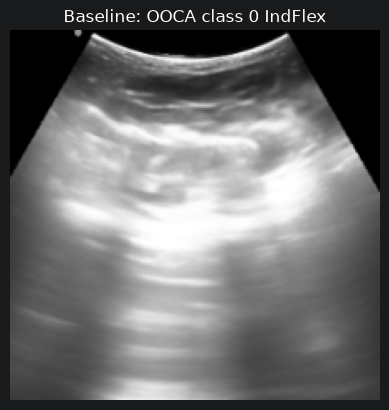

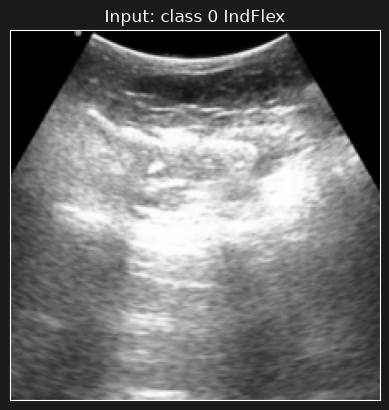

DEBUG: attr_2d max: 0.1607920229434967, min: 0.0


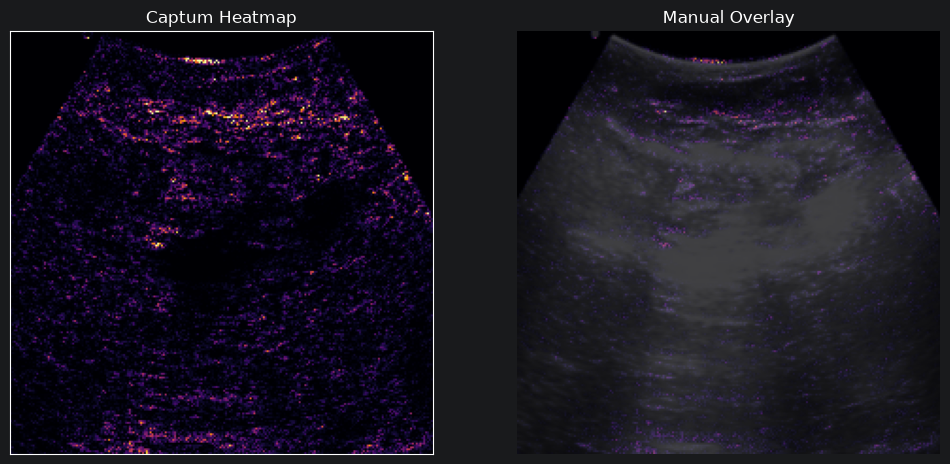

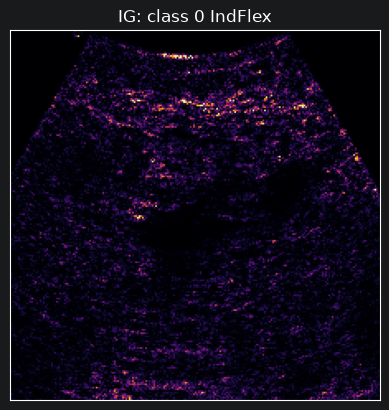

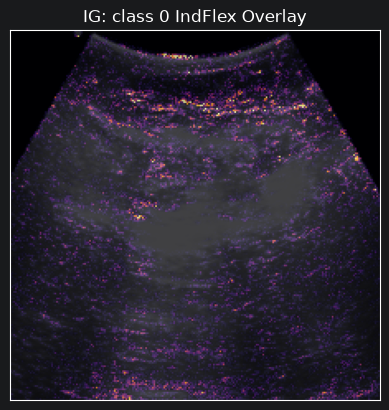

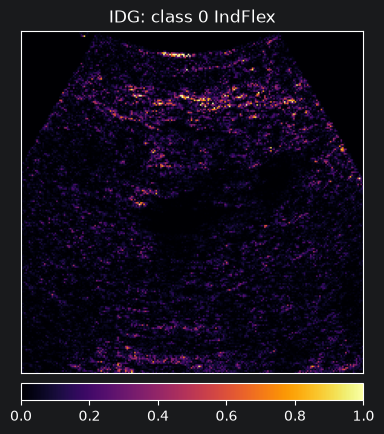

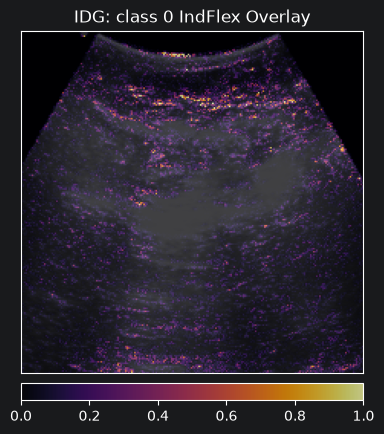

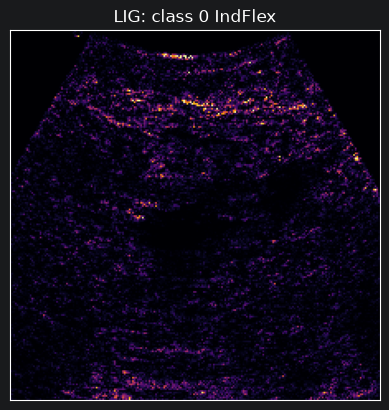

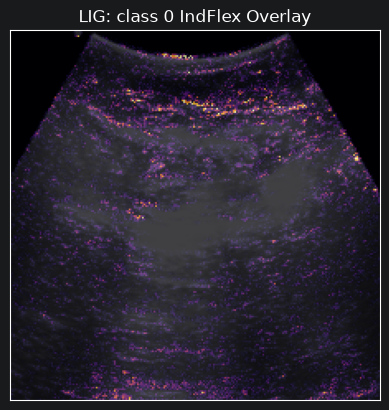

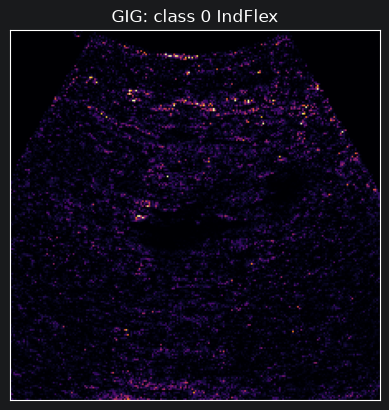

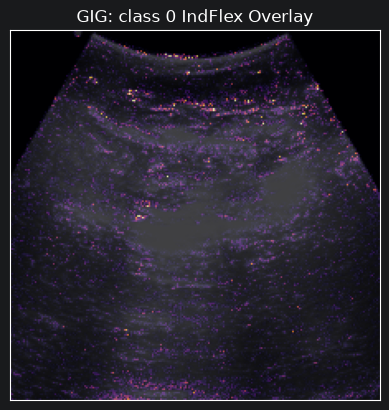

In [215]:
# transform the [C, H, W] image and attributions to [H, W, C] for display

def normalize_min_max(tensor: torch.Tensor) -> torch.Tensor:
    t_min = tensor.min()
    t_max = tensor.max()
    print(f"t_min, t_max: {t_min}, {t_max}")
    return (tensor - t_min) / (t_max - t_min)

print(f"trans_img.shape: {trans_img.shape}") # e.g. trans_img.shape: torch.Size([1, 224, 224])
print(f"trans_img.max: {trans_img.max()}")

# convert a grayscale image to RGB
# (captum expects an RGB image and has no option to display a grayscale image)
if trans_img.shape[0] == 1:
    trans_img = trans_img.repeat(3, 1, 1)

# TODO: make sure the .cpu() call makes sense here if using another device
# img_print = np.transpose(trans_img.squeeze().detach().cpu().numpy(), (1, 2, 0))
img_print = np.transpose(trans_img.detach().cpu().numpy(), (1, 2, 0))
# ig_print = np.transpose(ig.squeeze().detach().cpu().numpy(), (1,2,0))
print(f"ig.shape: {ig.shape}")
print(f"ig.max: {ig.max()}")
ig_chw = ig.unsqueeze(0)
# ig_print = np.transpose(ig.detach().cpu().numpy(), (1, 2, 0))
ig_print = np.transpose(ig_chw.detach().cpu().numpy(), (1, 2, 0))
# lig_print = np.transpose(lig.squeeze().detach().cpu().numpy(), (1,2,0))
print(f"lig.shape: {lig.shape}")
print(f"lig.max: {lig.max()}")
lig_chw = lig.unsqueeze(0)
lig_print = np.transpose(lig_chw.detach().cpu().numpy(), (1, 2, 0))
# idg_print = np.transpose(idg.squeeze().detach().cpu().numpy(), (1,2,0))
print(f"idg.shape: {idg.shape}")
print(f"idg.min, idg.max: {idg.min()}, {idg.max()}")
# idg = normalize_min_max(idg)
# print(f"normalized idg.min, idg.max: {idg.min()}, {idg.max()}")
# idg = to_tensor(idg)
idg_chw = idg.unsqueeze(0)
idg_print = np.transpose(idg_chw.detach().cpu().numpy(), (1, 2, 0))
# gig_print = np.transpose(gig.squeeze().detach().cpu().numpy(), (1, 2, 0))
print(f"gig.shape: {gig.shape}")
print(f"gig.max: {gig.max()}")
gig_chw = gig.squeeze(0)
gig_print = np.transpose(gig_chw.detach().cpu().numpy(), (1, 2, 0))
if "adversarial_gradient_integration" in attribution_methods_to_include:
    agi_print = agi

# use 0 to 100 luminosity colormap
default_cmap = plt.get_cmap("inferno")

print(f"baseline.shape: {baseline.shape}")
print(f"img_print.shape: {img_print.shape}")

class_title_suffix: str = f"class {target_class} {test_class}"

# plt.imshow(img_print)
plt.imshow(baseline_numpy, cmap=plt.get_cmap("gray"))
plt.title(f"Baseline: OOCA {class_title_suffix}")
# plt.title(f"Baseline: black")
plt.axis('off')
plt.show()

# TODO: make a loop that creates a grid of multiple classes and IG techniques

# baseline image
# fig, _ = viz.visualize_image_attr(baseline_numpy,
#                                   baseline_numpy,
#                                   method="original_image",
#                                   title="Baseline",
#                                   cmap="gray",
#                                   plt_fig_axis = plt.subplots(1, 1))

# class sample image
# fig, _ = viz.visualize_image_attr(None,
# fig, _ = viz.visualize_image_attr(img_print,
#                             img_print,
#                             method="original_image",
#                             title=f"Input: {target_class} {test_class}",
#                             # cmap=plt.get_cmap("gray"),
#                             plt_fig_axis = plt.subplots(1, 1))

fig, ax = viz.visualize_image_attr(img_print,
                                  img_print,
                                  method="original_image",
                                  title=f"Input: {class_title_suffix}",
                                  # cmap=plt.get_cmap("gray"),
                                  plt_fig_axis = plt.subplots(1, 1))

fig.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
fig.suptitle("test title")
ax.set_title("HERE")
ax.set_axis_off()
ax.margins(0)
ax.xaxis.set_major_locator(plt.NullLocator())
ax.yaxis.set_major_locator(plt.NullLocator())

# 4. Optional: If saving, use these flags to prevent the border from returning
# plt.savefig("output.png", bbox_inches='tight', pad_inches=0)

plt.show()
plt.close()


# ig_print_min = tf.reduce_min(ig_print)
# ig_print_max = tf.reduce_max(ig_print)
# print(f"ig_print_min:      {ig_print_min}, ig_print_max:      {ig_print_max}")
# ig_print_norm = (ig_print - ig_print_min) / (ig_print_max - ig_print_min + 1e-8)
# print(f"ig_print_norm_min: {tf.reduce_min(ig_print_norm)}, ig_print_norm_max: {tf.reduce_max(ig_print_norm)}")
# 
# print(f"non-normalized IG:")
# plt.imshow(ig_print, cmap=plt.get_cmap("inferno"))
# plt.show()
# 
# print(f"normalized IG:")
# plt.imshow(ig_print_norm, cmap=plt.get_cmap("inferno"))
# plt.show()
# 
# # plot overlay
# fig2, ax2 = plt.subplots(1, 1)
# ax2.imshow(img_print, cmap=plt.get_cmap("gray"))
# ax2.imshow(ig_print_norm, alpha=0.4, cmap=plt.get_cmap("inferno"))
# ax2.axis('off')
# plt.tight_layout()
# plt.show()
# 

heatmap_overlay_alpha: float = 0.75
# TEST

# Ensure data is on CPU and in correct shape for manual plotting
# img_print should be (H, W, 3), ig_print should be (H, W, 1)
bg_img = img_print.copy()
if bg_img.max() > 1.0:
    bg_img /= 255.0

# Pre-calculate the attribution overlay to ensure it has data
attr_2d = np.abs(ig_print.squeeze())
# Check if it's all zeros
print(f"DEBUG: attr_2d max: {attr_2d.max()}, min: {attr_2d.min()}")

# Robust normalization
denom = attr_2d.max() - attr_2d.min()
if denom > 0:
    attr_norm = (attr_2d - attr_2d.min()) / denom
else:
    attr_norm = attr_2d

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# --- AX 2 FIRST (Manual) ---
# We do this first because Captum's call might trigger a flush/show
ax2.imshow(bg_img)
ax2.imshow(attr_norm, cmap=default_cmap, alpha=heatmap_overlay_alpha)
ax2.set_title("Manual Overlay")
ax2.axis('off')

# --- AX 1 SECOND (Captum) ---
viz.visualize_image_attr(ig_print,
                         img_print,
                         method='heat_map',
                         title="Captum Heatmap",
                         cmap=default_cmap,
                         sign='absolute_value',
                         show_colorbar=False,
                         plt_fig_axis=(fig1, ax1))

plt.show()


# end TEST


# fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# fig, _ = viz.visualize_image_attr(ig_print,
fig, _ = viz.visualize_image_attr(ig_print,
                                  img_print,
                                  method='heat_map',
                                  # method='blended_heat_map',
                                  title=f"IG: {class_title_suffix}",
                                  cmap=default_cmap,
                                  sign='absolute_value',
                                  show_colorbar=False,
                                  plt_fig_axis = plt.subplots(1, 1))
                                  # plt_fig_axis = (fig1, ax1))

# fig, ax2 = viz.visualize_image_attr(ig_print,
_ = viz.visualize_image_attr(ig_print,
                            img_print,
                            # method='heat_map',
                            method='blended_heat_map',
                            title=f"IG: {class_title_suffix} Overlay",
                            cmap=default_cmap,
                            alpha_overlay=heatmap_overlay_alpha,
                            sign='absolute_value',
                            show_colorbar=False,
                            plt_fig_axis = plt.subplots(1, 1))
                            # plt_fig_axis = (fig1, ax2))

# plt.tight_layout()
# plt.show()
# plt.close()




fig, _ = viz.visualize_image_attr(idg_print,
                            img_print,
                            method='heat_map',
                            title=f"IDG: {class_title_suffix}",
                            cmap=default_cmap,
                            sign='absolute_value',
                                  show_colorbar=True,
                            plt_fig_axis = plt.subplots(1, 1))

fig, _ = viz.visualize_image_attr(idg_print,
                                  img_print,
                                  # method='heat_map',
                                  method='blended_heat_map',
                                  title=f"IDG: {class_title_suffix} Overlay",
                                  cmap=default_cmap,
                                  sign='absolute_value',
                                  alpha_overlay=heatmap_overlay_alpha,
                                  show_colorbar=True,
                                  plt_fig_axis = plt.subplots(1, 1))


fig, _ = viz.visualize_image_attr(lig_print,
                            img_print,
                            method='heat_map',
                            title=f"LIG: {class_title_suffix}",
                            cmap=default_cmap,
                            sign='absolute_value',
                            plt_fig_axis = plt.subplots(1, 1))

fig, _ = viz.visualize_image_attr(lig_print,
                                  img_print,
                                  method='blended_heat_map',
                                  title=f"LIG: {class_title_suffix} Overlay",
                                  cmap=default_cmap,
                                  sign='absolute_value',
                                  alpha_overlay=heatmap_overlay_alpha,
                                  plt_fig_axis = plt.subplots(1, 1))

fig, _ = viz.visualize_image_attr(gig_print,
                            img_print,
                            method='heat_map',
                            title=f"GIG: {class_title_suffix}",
                            cmap=default_cmap,
                            sign='absolute_value',
                            plt_fig_axis = plt.subplots(1, 1))

fig, _ = viz.visualize_image_attr(gig_print,
                                  img_print,
                                  method='blended_heat_map',
                                  title=f"GIG: {class_title_suffix} Overlay",
                                  cmap=default_cmap,
                                  sign='absolute_value',
                                  alpha_overlay=heatmap_overlay_alpha,
                                  plt_fig_axis = plt.subplots(1, 1))

if "adversarial_gradient_integration" in attribution_methods_to_include:
    fig, _ = viz.visualize_image_attr(agi_print,
                                img_print,
                                method='heat_map',
                                title=f"AGI: {class_title_suffix}",
                                cmap=default_cmap,
                                sign='absolute_value',
                                plt_fig_axis = plt.subplots(1, 1))
